# Dividing the samples for microarray and rna seq depending on the clases
- Age group
- Sex
- Excersise levels
- Sarcopenia vs non sarcopenia
- Country

In [1]:
import pandas as pd
import feature_selection as fs
import model as m
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

2024-04-30 15:13:04.767350: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-04-30 15:13:04.770810: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-04-30 15:13:04.825662: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-30 15:13:04.825701: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-30 15:13:04.827182: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

## RNAseq

First I will add the metadata that was missing


In [123]:
dataset_path = 'Data/RNAseq_All_abundances_adjusted.csv'
data_df = pd.read_csv(dataset_path)
metadata_path = "Data/All_rna_samples_metadata.csv"
metadata_df = pd.read_csv(metadata_path)

In [124]:
data_df.set_index('Sample', inplace=True)
metadata_df.set_index('Run', inplace=True)

In [125]:
data_df

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Experiment,Age
Sample,,,,,,,,,,,,,,,,,,,,,
SRR13388732,-0.025109,-0.028258,-0.005872,-0.026729,-0.026472,-0.027634,-0.020870,-0.022772,-0.022661,-0.025610,...,-0.028169,-0.028120,-0.028027,-0.027546,-0.028289,-0.028272,-0.024716,-0.028265,GSE164471,23.0
SRR13388733,-0.026260,-0.033508,-0.004524,-0.028312,-0.031995,-0.032750,-0.016343,-0.026733,-0.023806,-0.026443,...,-0.033510,-0.033522,-0.033509,-0.032635,-0.033518,-0.033482,-0.020903,-0.032705,GSE164471,28.0
SRR13388734,-0.030608,-0.037952,-0.002987,-0.034886,-0.029932,-0.038745,-0.014741,-0.030696,-0.027022,-0.031814,...,-0.038155,-0.039709,-0.039524,-0.038657,-0.039251,-0.039648,-0.036926,-0.038901,GSE164471,31.0
SRR13388735,-0.021728,-0.024309,-0.004225,-0.022910,-0.023840,-0.024011,-0.019799,-0.021443,-0.022365,-0.022526,...,-0.024390,-0.024440,-0.024351,-0.023795,-0.024435,-0.024431,-0.021008,-0.024095,GSE164471,31.0
SRR13388736,-0.019503,-0.034629,-0.004944,-0.031244,-0.026323,-0.034354,-0.021341,-0.015501,-0.017102,-0.031354,...,-0.034285,-0.033820,-0.034226,-0.033922,-0.035173,-0.035132,-0.031649,-0.034687,GSE164471,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR8882198,-0.019750,-0.021331,-0.005098,-0.020260,-0.021419,-0.020946,-0.018419,-0.019666,-0.019176,-0.019744,...,-0.021333,-0.021377,-0.021335,-0.020852,-0.021341,-0.021372,-0.020049,-0.021263,GSE129643,27.0
SRR8882200,-0.017618,-0.019354,-0.003957,-0.018234,-0.019187,-0.019024,-0.016646,-0.017455,-0.018713,-0.018467,...,-0.019334,-0.019429,-0.019360,-0.018994,-0.019396,-0.019424,-0.018100,-0.019367,GSE129643,33.0
SRR8882202,-0.018818,-0.020237,-0.003773,-0.018901,-0.020455,-0.019962,-0.016610,-0.018502,-0.018296,-0.018516,...,-0.020258,-0.020326,-0.020308,-0.019834,-0.020319,-0.020318,-0.018674,-0.020279,GSE129643,37.0


In [126]:
metadata_df["Experiment"].unique()

array(['GSE167186', 'GSE157585', 'GSE164471', 'GSE152558', 'GSE129643',
       'GSE60590'], dtype=object)

In [127]:
extended_data_df = data_df.merge(metadata_df, left_index=True, right_index=True)
extended_data_df.drop(columns=['Age_y'], inplace=True)
extended_data_df["Age"]=extended_data_df["Age_x"]
extended_data_df.drop(columns=['Age_x'], inplace=True)
extended_data_df["Experiment"]=extended_data_df["Experiment_x"]
extended_data_df.drop(columns=['Experiment_x', "Experiment_y"], inplace=True)
extended_data_df

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Status,Sex,Age,Experiment
SRR13388732,-0.025109,-0.028258,-0.005872,-0.026729,-0.026472,-0.027634,-0.020870,-0.022772,-0.022661,-0.025610,...,-0.028027,-0.027546,-0.028289,-0.028272,-0.024716,-0.028265,Healthy,male,23.0,GSE164471
SRR13388733,-0.026260,-0.033508,-0.004524,-0.028312,-0.031995,-0.032750,-0.016343,-0.026733,-0.023806,-0.026443,...,-0.033509,-0.032635,-0.033518,-0.033482,-0.020903,-0.032705,Healthy,male,28.0,GSE164471
SRR13388734,-0.030608,-0.037952,-0.002987,-0.034886,-0.029932,-0.038745,-0.014741,-0.030696,-0.027022,-0.031814,...,-0.039524,-0.038657,-0.039251,-0.039648,-0.036926,-0.038901,Healthy,male,31.0,GSE164471
SRR13388735,-0.021728,-0.024309,-0.004225,-0.022910,-0.023840,-0.024011,-0.019799,-0.021443,-0.022365,-0.022526,...,-0.024351,-0.023795,-0.024435,-0.024431,-0.021008,-0.024095,Healthy,male,31.0,GSE164471
SRR13388736,-0.019503,-0.034629,-0.004944,-0.031244,-0.026323,-0.034354,-0.021341,-0.015501,-0.017102,-0.031354,...,-0.034226,-0.033922,-0.035173,-0.035132,-0.031649,-0.034687,Healthy,female,35.0,GSE164471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR8882198,-0.019750,-0.021331,-0.005098,-0.020260,-0.021419,-0.020946,-0.018419,-0.019666,-0.019176,-0.019744,...,-0.021335,-0.020852,-0.021341,-0.021372,-0.020049,-0.021263,Healthy,female,27.0,GSE129643
SRR8882200,-0.017618,-0.019354,-0.003957,-0.018234,-0.019187,-0.019024,-0.016646,-0.017455,-0.018713,-0.018467,...,-0.019360,-0.018994,-0.019396,-0.019424,-0.018100,-0.019367,Healthy,male,33.0,GSE129643
SRR8882202,-0.018818,-0.020237,-0.003773,-0.018901,-0.020455,-0.019962,-0.016610,-0.018502,-0.018296,-0.018516,...,-0.020308,-0.019834,-0.020319,-0.020318,-0.018674,-0.020279,Healthy,male,37.0,GSE129643
SRR8882203,-0.017649,-0.018998,-0.003477,-0.017604,-0.019472,-0.018760,-0.016018,-0.017490,-0.017853,-0.017664,...,-0.019036,-0.018651,-0.019067,-0.019071,-0.017318,-0.019013,Healthy,male,38.0,GSE129643


In [128]:
extended_data_df["Status"].unique()

array(['Healthy', 'Sarcopenia', 'UNCLASSIFIED', 'trained', 'untrained'],
      dtype=object)

In [131]:
extended_data_df[extended_data_df["Status"] == "UNCLASSIFIED"]
#extended_data_df[extended_data_df["Experiment"] == "GSE167186"]

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Status,Sex,Age,Experiment
SRR13758988,-0.029136,-0.028181,-0.003953,-0.024714,-0.026229,-0.027303,-0.017892,-0.022398,-0.020686,-0.024766,...,-0.027965,-0.027568,-0.028033,-0.028056,-0.024663,-0.027872,UNCLASSIFIED,NaN,71.0,GSE167186
SRR13758995,-0.025277,-0.027101,-0.003939,-0.024844,-0.024722,-0.026382,-0.019927,-0.020537,-0.020384,-0.024006,...,-0.026921,-0.023278,-0.026994,-0.027023,-0.026556,-0.026831,UNCLASSIFIED,NaN,78.0,GSE167186
SRR13759028,-0.027086,-0.026545,-0.004039,-0.024437,-0.024524,-0.025908,-0.019950,-0.018388,-0.019579,-0.023615,...,-0.026384,-0.023295,-0.026459,-0.026490,-0.017526,-0.026295,UNCLASSIFIED,NaN,71.0,GSE167186
SRR13759037,-0.021256,-0.025461,-0.003651,-0.023643,-0.023849,-0.024983,-0.019143,-0.020970,-0.019655,-0.022851,...,-0.025335,-0.021488,-0.025415,-0.025452,-0.022961,-0.025250,UNCLASSIFIED,NaN,71.0,GSE167186


In [6]:
def plot_coefs(result, threshold=0.05, line_t=0.05):
    plt.figure(figsize=(10, 6))
    plt.plot(result[result["abs_coef"]>threshold]["abs_coef"])
    plt.xlabel('Feature')
    plt.ylabel('Coefficient')
    #plt.title('Feature Coefficients')
    #plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    #plt.grid(True)
    plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    plt.axhline(y=line_t, color='r', linestyle='--', label="y=0.1")
    plt.tight_layout()
    plt.show()


In [7]:
def get_subset(extended_data_df, class_name, category_name):
    section_df=extended_data_df[extended_data_df[class_name] == category_name]
    section_df = m.remove_non_numeric_columns(section_df)
    return section_df

In [8]:
def get_feature_from_class(extended_data_df, class_name, category_name, alpha=0.1):
    section_df= get_subset(extended_data_df, class_name, category_name)
    section_df_age = section_df["Age"]
    section_df.drop(columns=["Age"], inplace=True)
    features, coef = fs.ridge_L2(X=section_df, y=section_df_age, alpha=alpha)
    result = pd.DataFrame(list(features), coef, columns=["coef"])
    result["abs_coef"]=result["coef"].abs()
    result.sort_values(ascending=False, inplace=True, by="abs_coef")
    result
    return result


In [9]:
def plot_coef_pairs(df, first, second):
    plt.scatter(df[first], df[second])

    # Set labels and title
    plt.xlabel(first)
    plt.ylabel(second)
    plt.title(f'Plot of {first} vs {second}')

    # Show the plot
    plt.grid(True)
    plt.show()

Now I will separete them

In [12]:
female_features = get_feature_from_class(extended_data_df, category_name="female", class_name="Sex", alpha=0.1)



In [13]:
all_df = m.remove_non_numeric_columns(extended_data_df)
all_df_age = all_df["Age"]
all_df.drop(columns=["Age"], inplace=True)
all_df_features, all_df_coeficients = fs.ridge_L2(X=all_df, y=all_df_age, alpha=0.1)
all_df_result = pd.DataFrame(list(all_df_features), all_df_coeficients, columns=["coef"])
all_df_result["abs_coef"]=all_df_result["coef"].abs()
all_df_result.sort_values(ascending=False, inplace=True, by="abs_coef")


In [14]:
selected_features = pd.DataFrame(all_df_result.index, columns=["Feature"])
selected_features.set_index("Feature", inplace=True)
selected_features["all_df_coef"]=all_df_result["abs_coef"]
selected_features["female_coef"]=female_features["abs_coef"]
selected_features

,all_df_coef,female_coef
Feature,,
ENSG00000232177.1,8.151179e-01,0.210203
ENSG00000189058.8,6.970447e-01,0.500218
ENSG00000249072.1,6.461213e-01,0.266468
ENSG00000127720.7,6.295996e-01,0.024618
ENSG00000270388.1,5.957452e-01,0.115401
...,...,...
ENSG00000264006.7,1.047093e-06,0.001208
ENSG00000234360.1,8.338431e-07,0.001058
ENSG00000228767.1,5.086259e-07,0.000562


In [15]:
selected_features[selected_features["female_coef"]>0.05].sort_values(by="female_coef", ascending=False)

,all_df_coef,female_coef
Feature,,
ENSG00000189058.8,0.697045,0.500218
ENSG00000252747.1,0.037020,0.433826
ENSG00000256045.2,0.344282,0.372405
ENSG00000236073.2,0.355037,0.349231
ENSG00000251920.1,0.103554,0.329514
...,...,...
ENSG00000184588.17,0.107044,0.050280
ENSG00000115084.13,0.035066,0.050268
ENSG00000222302.1,0.079848,0.050181


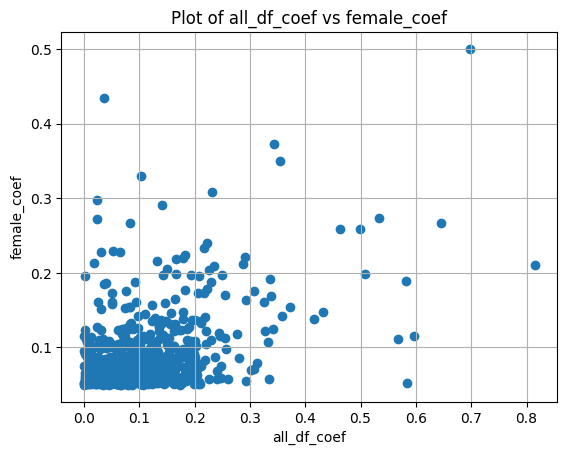

In [16]:
df =selected_features[selected_features["female_coef"]>0.05].sort_values(by="all_df_coef", ascending=False)
plot_coef_pairs(df, "all_df_coef", "female_coef")

In [17]:
selected_features[(selected_features["female_coef"]>0.3) | (selected_features["all_df_coef"] > 0.5)].sort_values(by="all_df_coef", ascending=False)

,all_df_coef,female_coef
Feature,,
ENSG00000232177.1,0.815118,0.210203
ENSG00000189058.8,0.697045,0.500218
ENSG00000249072.1,0.646121,0.266468
ENSG00000127720.7,0.629600,0.024618
ENSG00000270388.1,0.595745,0.115401
ENSG00000255633.5,0.583679,0.052339
ENSG00000233494.1,0.582875,0.188847
ENSG00000199455.1,0.567228,0.110765
ENSG00000185885.15,0.544495,0.001468


In [18]:
male_features = get_feature_from_class(extended_data_df, category_name="male", class_name="Sex", alpha=0.1)
#plot_coefs(male_features, threshold=0.005, line_t=0.05)

In [19]:
sarcopenia_features = get_feature_from_class(extended_data_df, category_name="Sarcopenia", class_name="Status", alpha=0.1)
#plot_coefs(sarcopenia_features, threshold=0.005, line_t=0.05)

In [20]:
trained_features = get_feature_from_class(extended_data_df, category_name="trained", class_name="Status", alpha=0.1)
#plot_coefs(trained_features, threshold=0.005, line_t=0.05)

In [21]:
extended_data_df["Status"].unique()

array(['Healthy', 'Sarcopenia', 'UNCLASSIFIED', 'trained', 'untrained'],
      dtype=object)

In [22]:
selected_features["sarcopenia_coef"]=sarcopenia_features["abs_coef"]
selected_features["male_coef"]=male_features["abs_coef"]
selected_features["trained_coef"]=trained_features["abs_coef"]
selected_features

,all_df_coef,female_coef,sarcopenia_coef,male_coef,trained_coef
Feature,,,,,
ENSG00000232177.1,8.151179e-01,0.210203,0.005052,0.264606,5.192385e-04
ENSG00000189058.8,6.970447e-01,0.500218,0.000087,0.180651,2.577251e-04
ENSG00000249072.1,6.461213e-01,0.266468,0.000816,0.129817,1.899361e-04
ENSG00000127720.7,6.295996e-01,0.024618,0.002903,0.251608,3.032746e-04
ENSG00000270388.1,5.957452e-01,0.115401,0.004848,0.315227,1.806902e-04
...,...,...,...,...,...
ENSG00000264006.7,1.047093e-06,0.001208,0.000038,0.001073,2.741841e-07
ENSG00000234360.1,8.338431e-07,0.001058,0.000038,0.000635,1.639352e-06
ENSG00000228767.1,5.086259e-07,0.000562,0.000038,0.000396,1.639352e-06


In [23]:
#selected_features[selected_features.isna().any(axis=1)]
selected_features.dropna(inplace=True)
selected_features

,all_df_coef,female_coef,sarcopenia_coef,male_coef,trained_coef
Feature,,,,,
ENSG00000232177.1,8.151179e-01,0.210203,0.005052,0.264606,5.192385e-04
ENSG00000189058.8,6.970447e-01,0.500218,0.000087,0.180651,2.577251e-04
ENSG00000249072.1,6.461213e-01,0.266468,0.000816,0.129817,1.899361e-04
ENSG00000127720.7,6.295996e-01,0.024618,0.002903,0.251608,3.032746e-04
ENSG00000270388.1,5.957452e-01,0.115401,0.004848,0.315227,1.806902e-04
...,...,...,...,...,...
ENSG00000264006.7,1.047093e-06,0.001208,0.000038,0.001073,2.741841e-07
ENSG00000234360.1,8.338431e-07,0.001058,0.000038,0.000635,1.639352e-06
ENSG00000228767.1,5.086259e-07,0.000562,0.000038,0.000396,1.639352e-06


In [10]:
import os

def create_new_folder(base_path="Data", data_type = "RNA"):
    # Check if the Results directory exists, if not, create it
    results_dir = os.path.join(base_path, f"Divided_samples_{data_type}")
    if not os.path.exists(results_dir):
        os.makedirs(results_dir)

    # Find existing result folders and determine the next number
    existing_folders = [name for name in os.listdir(results_dir) if os.path.isdir(os.path.join(results_dir, name))]
    if not existing_folders:
        next_number = 1
    else:
        # Sort existing folders to get the highest numbered folder
        existing_folders.sort()
        last_folder = existing_folders[-1]
        last_number = int(last_folder.replace("dataset", ""))
        next_number = last_number + 1

    # Generate the name for the new folder
    new_folder_name = "dataset{:02d}".format(next_number)
    new_folder_path = os.path.join(results_dir, new_folder_name)

    # Create the new folder
    os.makedirs(new_folder_path)

    return new_folder_path

In [40]:
datasets=[("Sex", "female"), ("Sex", "male"),
          ("Status", "Sarcopenia"), ("Status", "trained"),
          ("Status", "Healthy"), ("Status", "untrained"),
          ("Experiment", "GSE167186"), ("Experiment", "GSE157585"),
          ("Experiment", "GSE164471"), ("Experiment", "GSE152558"),
          ("Experiment", "GSE129643"), ("Experiment", "GSE60590")]

for dataset in datasets:
    data = get_subset(extended_data_df, category_name=dataset[1], class_name=dataset[0])
    cls = data.columns[-1]
    data.index.name="Sample"
    
    data.to_csv(f"Data/divided_datasets/RNAseq/{dataset[0]}_{dataset[1]}.csv", index=True, header=True)
          

In case I forgot any (like untrained)

In [134]:
category_name= "Healthy"
class_name = "Status"
data = get_subset(extended_data_df, category_name=category_name, class_name= class_name)
data.index.name="Sample"
data.to_csv(f"Data/divided_datasets/RNAseq/{class_name}_{category_name}.csv", index=True, header=True)

## Microarray

In [2]:
microRNA_orginal = pd.read_csv('Data/microarray_clean_reCombat.csv')

additional_df = pd.read_csv("Data/trainign_dataset_51270_microarray_adjusted.csv")

additional_df = additional_df[["Sample", "Sex", "Status"]]

# Merge the additional DataFrame with the main DataFrame based on the "Sample" column
data_df = pd.merge(microRNA_orginal, additional_df, on="Sample", how="left")

/tmp/ipykernel_100949/448292903.py:3: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  additional_df = pd.read_csv("Data/trainign_dataset_51270_microarray_adjusted.csv")


In [15]:
data_df

,U48705,M87338,X51757,X69699,L36861,L13852,X55005,X79510,M21121,J02843,...,AA149545,C18318,AI219073,AI205180,AI363375,Experiment_x,Age,Sex,Status,Experiment_y
Sample,,,,,,,,,,,,,,,,,,,,,
GSM342683,-1.255312,0.620507,1.990971,0.121714,0.874350,0.131603,-0.082265,0.664024,0.054585,0.013871,...,-0.581037,0.143219,-0.021384,-0.160995,-0.049067,GSE13070,45.51,unknow,NRd,GSE13070
GSM342684,0.083927,-1.898141,0.589784,-0.483230,-0.031845,-0.509871,-1.701369,-0.343734,-0.269988,0.222006,...,-0.225956,-0.210968,-0.120172,-0.259769,0.059888,GSE13070,46.04,Male,NRd,GSE13070
GSM342689,0.628723,0.555853,-0.081090,-1.904009,0.184652,-0.112731,-0.316003,2.796468,0.055688,0.426448,...,1.090838,0.158646,0.113305,-0.222022,0.229103,GSE13070,43.39,Male,NRd,GSE13070
GSM342690,1.735575,-0.331097,-0.250555,0.398203,0.468242,-0.024928,0.116207,0.322334,0.493728,0.145599,...,-0.365231,0.480421,0.152346,0.209922,0.086124,GSE13070,43.37,Male,NRd,GSE13070
GSM342695,-1.907410,2.047293,0.489875,-0.652065,-0.946984,0.154030,-0.535365,-1.807169,-0.591299,-0.271906,...,0.343653,-0.444957,0.000579,-0.170443,-0.251319,GSE13070,44.40,Male,NRd,GSE13070
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM244612,1.708436,0.597657,-1.159295,1.297905,1.045859,1.459585,3.526321,3.221477,-0.801564,1.769470,...,0.040127,0.039429,0.037750,0.037564,0.034719,GSE9676,65.10,Female,NaN,GSE9676
GSM244613,-0.984965,-2.141692,-1.629989,-1.285400,2.335933,0.091776,-3.204698,1.755974,-0.438364,0.482434,...,-0.009549,-0.009560,-0.009328,-0.009296,-0.008741,GSE9676,68.40,Female,NaN,GSE9676
GSM244614,3.589671,-0.485288,0.835317,2.108831,3.383992,0.371828,0.243863,2.765636,-0.251110,1.345676,...,-0.239968,-0.236793,-0.227699,-0.226651,-0.210328,GSE9676,65.90,Female,NaN,GSE9676


In [3]:
del microRNA_orginal

In [4]:
#dataset_path = 'Data/trainign_dataset_51270_microarray_adjusted.csv'
#data_df = pd.read_csv(dataset_path)

data_df.set_index('Sample', inplace=True)
data_df["Status"].unique()

array(['NRd', nan, 'T2DM', 'obsese', 'obsese after 8-week training',
       'exercise group: A (Mild aerobic exercise)',
       'exercise group: B (Inactive control)',
       'exercise group: C (High aerobic exercise)',
       'exercise group: D (Moderate aerobic exercise)',
       'exercise group: E (Aerobic + Resistance exercise)',
       'exercise group: F (Resistance exercise)', 'Menopause', 'nPOS',
       'POS', 'Sedentary', 'Trained'], dtype=object)

In [11]:
category_name= "nPOS"
class_name = "Status"
data = get_subset(data_df, category_name=category_name, class_name= class_name)
data.index.name="Sample"
data.to_csv(f"Data/divided_datasets/microarray/{class_name}_{category_name}.csv", index=True, header=True)

In [12]:
#data_df[data_df["Status"]=="IRd"]["Experiment"]
# IRd is Insulin resistant so it must be eliminated
data_df = data_df[~data_df["Status"].fillna('').str.contains("IRd")]


In [13]:
#data_df[data_df["Status"]=="TZD"]
#TZD is a medication, should be eliminated
data_df = data_df[~data_df["Status"].fillna('').str.contains("TZD")]


In [16]:
#data_df[data_df["Status"]=="RYGB"]["Experiment"]

#RYGB is a surgery so it must be eliminated
data_df = data_df[~data_df["Status"].fillna('').str.contains("RYGB")]


In [17]:
data_df["Status"].unique()

array(['NRd', nan, 'T2DM', 'obsese', 'obsese after 8-week training',
       'exercise group: A (Mild aerobic exercise)',
       'exercise group: B (Inactive control)',
       'exercise group: C (High aerobic exercise)',
       'exercise group: D (Moderate aerobic exercise)',
       'exercise group: E (Aerobic + Resistance exercise)',
       'exercise group: F (Resistance exercise)', 'Menopause', 'nPOS',
       'POS', 'Sedentary', 'Trained'], dtype=object)

In [18]:
x= data_df[data_df["Status"].isna() ]
data_df[data_df['Experiment_x']=="GSE161643"]


,U48705,M87338,X51757,X69699,L36861,L13852,X55005,X79510,M21121,J02843,...,AA149545,C18318,AI219073,AI205180,AI363375,Experiment_x,Age,Sex,Status,Experiment_y
Sample,,,,,,,,,,,,,,,,,,,,,
GSM4911727,0.788976,0.691614,-0.579477,-1.460314,-0.367968,-0.357007,0.788374,-0.122300,-0.237534,0.019715,...,0.713688,-0.045045,-0.153880,-0.200043,-0.125615,GSE161643,49.0,Female,T2DM,GSE161643
GSM4911729,0.720392,0.091443,0.085540,-0.398469,-0.145525,0.019157,-1.328481,0.117091,-0.091350,0.079677,...,0.546074,0.273778,0.132923,-0.056977,0.140723,GSE161643,41.0,Female,T2DM,GSE161643
GSM4911731,-1.093514,0.008980,-0.092088,0.223790,-0.462683,-0.318447,-0.198193,-0.101768,-0.198943,-0.053502,...,-0.550374,-0.137218,-0.225805,-0.011207,0.043398,GSE161643,34.0,Female,T2DM,GSE161643
GSM4911733,-1.341070,-0.019638,-0.314817,-1.067125,0.059148,-0.167686,-0.791749,-0.156374,-0.117590,-0.066252,...,-0.891063,0.162707,-0.065484,0.159196,-0.128448,GSE161643,39.0,Female,T2DM,GSE161643
GSM4911735,-1.497309,0.371941,0.015527,0.110615,-0.022396,-0.510343,-1.636813,-0.095533,-0.213647,0.220295,...,-0.137767,-0.239311,0.050299,0.210241,0.092449,GSE161643,46.0,Female,T2DM,GSE161643
GSM4911737,-0.094009,0.269126,-0.011567,0.301638,0.080682,-0.237361,-1.494480,-0.189740,-0.191655,-0.116043,...,-0.215697,-0.354854,-0.024288,0.001371,-0.007003,GSE161643,35.0,Female,T2DM,GSE161643
GSM4911739,-1.120232,-0.433209,0.153671,1.352410,0.047942,0.046930,-2.755723,0.187350,-0.198361,0.022266,...,-0.687909,0.125972,0.111752,0.038467,-0.092250,GSE161643,50.0,Female,T2DM,GSE161643
GSM4911741,1.400909,-0.520081,0.030306,-0.460131,-0.547508,0.106542,1.714449,-0.323215,0.648722,-0.490390,...,0.256076,0.045187,-0.172166,-0.329871,-0.115381,GSE161643,50.0,Female,NaN,GSE161643
GSM4911743,-0.894468,-0.715645,-0.180912,-2.013606,-0.005970,-0.796843,1.987676,-0.000510,-0.164096,-0.007838,...,-0.661399,-0.150476,0.004440,0.097254,-0.112912,GSE161643,60.0,Female,NaN,GSE161643


In [19]:
# T2DM is obese
data_df["Status"].replace({"T2DM": "Obese"}, inplace=True)
data_df["Status"].replace({"obsese": "Obese"}, inplace=True)
#data_df[data_df['Experiment']=="GSE161643"]

/tmp/ipykernel_100949/867136910.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_df["Status"].replace({"T2DM": "Obese"}, inplace=True)


In [20]:
# Replace all the ones that contain "exercise group:"" with "Trained"
data_df["Status"].replace({"exercise group:.*": "Trained"}, inplace=True, regex=True)
data_df["Status"].unique()

array(['NRd', nan, 'Obese', 'obsese after 8-week training', 'Trained',
       'Menopause', 'nPOS', 'POS', 'Sedentary'], dtype=object)

In [21]:
# replace 'NRd', nan, 'Menopause' and 'nPOS' with 'Healthy'
data_df["Status"].replace({"NRd": "Healthy"}, inplace=True)
data_df["Status"].replace({"Menopause": "Healthy"}, inplace=True)
data_df["Status"].replace({"nPOS": "Healthy"}, inplace=True)
data_df["Status"].replace({np.nan: "Healthy"}, inplace=True)
data_df["Status"].unique()

array(['Healthy', 'Obese', 'obsese after 8-week training', 'Trained',
       'POS', 'Sedentary'], dtype=object)

In [22]:
data_df["Status"].describe()
# count how many obsese
data_df["Experiment_x"].count()

522

In [23]:
data_df["Sex"].unique()
# how many unknow
data_df[data_df["Sex"]=="unknow"]
data_df["Sex"].replace({"unknow": "Male"}, inplace=True)


/tmp/ipykernel_100949/3523068006.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_df["Sex"].replace({"unknow": "Male"}, inplace=True)


In [29]:
data_df["Status"].replace({"obsese after 8-week training": "Obese"}, inplace=True)
# replace those that are experiment GSE8157 and status Healty with nPOS in status


/tmp/ipykernel_100949/3222252409.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_df["Status"].replace({"obsese after 8-week training": "Obese"}, inplace=True)


In [24]:
data_df["Status"].unique()

array(['Healthy', 'Obese', 'obsese after 8-week training', 'Trained',
       'POS', 'Sedentary'], dtype=object)

In [25]:
data_df["Experiment"]=data_df["Experiment_x"]
data_df.drop(columns=['Experiment_x', "Experiment_y"], inplace=True)

Save the clean one

In [26]:
data_df.to_csv(f"Data/RNAseq_abundances_adjusted_recombat_w_lables.csv", index=True, header=True)

data_df["Sex"]

In [27]:
data_df["Sex"]

Sample
GSM342683      Male
GSM342684      Male
GSM342689      Male
GSM342690      Male
GSM342695      Male
              ...  
GSM244612    Female
GSM244613    Female
GSM244614    Female
GSM244615    Female
GSM244616    Female
Name: Sex, Length: 522, dtype: object

In [28]:
datasets=[("Sex", "Female"), ("Sex", "Male"),
          ("Status", "Healthy"), 
          ("Status", "Trained"), ("Status", "Sedentary"),
          ("Status", "POS"), ("Status", "Sedentary"), ("Status", "Obese")]
for experiment in data_df["Experiment"].unique():
    datasets.append(("Experiment", experiment))

for dataset in datasets:
    data = get_subset(data_df, category_name=dataset[1], class_name=dataset[0])
    cls = data.columns[-1]
    data.index.name="Sample"
    data.to_csv(f"Data/divided_datasets/microarray/{dataset[0]}_{dataset[1]}.csv", index=True, header=True)

In [100]:
data_df["Sex"].replace({"male": "Male"}, inplace=True)


In [30]:
category_name= "Obese"
class_name = "Status"
data = get_subset(data_df, category_name=category_name, class_name= class_name)
data.index.name="Sample"
data.to_csv(f"Data/divided_datasets/microarray/{class_name}_{category_name}.csv", index=True, header=True)